# 04 — Detecção de preços atípicos

**Pergunta:** dentro de um grupo de apresentações equivalentes (mesma substância, dose, forma e quantidade),
quais têm preço muito diferente das demais? E por quê?

Na EDA apareceram casos estranhos, como um grupo de diclofenaco com mediana perto de R$ 25
e preço máximo acima de R$ 600. Aqui investigamos esses casos de forma sistemática.

**Base:** `cmed_analise_*.csv`, gerado pelo `02_eda.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", context="notebook")

SEMENTE = 42
PASTA_PROCESSED = Path("../data/processed")
PASTA_FIGURAS = Path("../reports/figures")
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

def salvar(fig, nome):
    fig.savefig(PASTA_FIGURAS / f"{nome}.png", dpi=150, bbox_inches="tight")

ARQUIVO = sorted(PASTA_PROCESSED.glob("cmed_analise_*.csv"))[-1]
df = pd.read_csv(ARQUIVO)
print(ARQUIVO.name, df.shape)

cmed_analise_20260909.csv (10983, 33)


## 1. Método: z-score robusto

Para cada apresentação, medimos o quanto seu preço se afasta da **mediana do grupo**:

- trabalhamos com o **logaritmo do preço**, porque diferenças de preço são multiplicativas
  (2x mais caro importa igual para um remédio de R$ 10 ou de R$ 1.000);
- usamos **mediana e MAD** (desvio absoluto mediano) em vez de média e desvio padrão, porque
  a média é puxada justamente pelos valores atípicos que queremos encontrar;
- o fator 0,6745 deixa o z-score robusto na mesma escala do z-score comum.

Uma apresentação é marcada como atípica quando:
1. |z robusto| > 3,5 (limite usual na literatura para esse método); **e**
2. o preço é pelo menos 50% maior ou menor que a mediana do grupo.

A segunda regra evita marcar diferenças irrelevantes em grupos onde quase todos têm o mesmo preço
(MAD muito pequeno). Só analisamos grupos com pelo menos 4 apresentações.

In [2]:
Z_LIMITE = 3.5
RAZAO_MINIMA = 1.5
TAMANHO_MINIMO = 4

def detectar_atipicos(dados, chave):
    d = dados.dropna(subset=[chave]).copy()
    d["log_pmc"] = np.log10(d["pmc_sem_impostos"])
    d["tamanho_grupo"] = d.groupby(chave)["log_pmc"].transform("size")
    d = d[d["tamanho_grupo"] >= TAMANHO_MINIMO].copy()

    grupos = d.groupby(chave)
    d["mediana_grupo"] = 10 ** grupos["log_pmc"].transform("median")
    d["desvio_log"] = d["log_pmc"] - np.log10(d["mediana_grupo"])
    mad = d.groupby(chave)["desvio_log"].transform(lambda s: s.abs().median())
    d["z_robusto"] = 0.6745 * d["desvio_log"] / mad.replace(0, np.nan)
    d["razao_mediana"] = 10 ** d["desvio_log"]

    d["atipico"] = (
        (d["z_robusto"].abs() > Z_LIMITE)
        & ((d["razao_mediana"] >= RAZAO_MINIMA) | (d["razao_mediana"] <= 1 / RAZAO_MINIMA))
    )
    return d

COLUNAS_VER = ["produto", "laboratorio", "tipo_produto", "apresentacao",
               "pmc_sem_impostos", "mediana_grupo", "razao_mediana"]

## 2. Primeira rodada

In [3]:
rodada1 = detectar_atipicos(df, "grupo")
print(f"Apresentações analisadas: {len(rodada1):,} em {rodada1['grupo'].nunique():,} grupos")
print(f"Atípicas: {rodada1['atipico'].sum():,}")

rodada1[rodada1["atipico"]].nlargest(10, "razao_mediana")[COLUNAS_VER]

Apresentações analisadas: 4,812 em 620 grupos
Atípicas: 342


,produto,laboratorio,tipo_produto,apresentacao,pmc_sem_impostos,mediana_grupo,razao_mediana
8741,GRIPALCÊ UNO,BRASTERAPICA PHARMACEUTICA LTDA.,Similar,32 MG/ML SUS OR CT FR PLAS TRANS X 60 ML + CP MED,"2,079.83",32.57,63.85
3889,CLOTRIMAZOL,BELFAR LTDA,Genérico,10 MG/G CREM DERM CT 50 BG AL X 20 G,702.56,15.53,45.24
10164,SULFATO DE NEOMICINA + BACITRACINA ZÍNCICA,BELFAR LTDA,Genérico,(5 MG + 250 UI)/G POM DERM CT 50 BG AL X 15 G,634.66,18.79,33.77
10165,SULFATO DE NEOMICINA + BACITRACINA ZÍNCICA,BELFAR LTDA,Genérico,(5 MG + 250 UI)/G POM DERM CT 50 BG AL X 10 G,423.40,13.83,30.61
385,BENZOL,GREENPHARMA QUÍMICA E FARMACÊUTICA LTDA,Similar,40 MG/ML SUS OR CT 50 FR VD AMB X 10 ML,313.15,11.11,28.18
7841,METRONIDAZOL,BELFAR LTDA,Genérico,100 MG/G GEL VAG CT 25 BG AL X 50G + 250 APLIC,712.37,33.49,21.27
105,DEXAGREEN,GREENPHARMA QUÍMICA E FARMACÊUTICA LTDA,Similar,1 MG/G CREM DERM CT 50 BG AL X 10 G (EMB HOSP),194.95,12.15,16.05
2509,BRONQTRAT,NATULAB LABORATORIO S.A,Similar,3 MG/ML XPE CT 50 FR PLAS AMB X 100 ML + 50 COP,367.74,25.75,14.28
2822,CIPRO,BAYER S.A.,Novo,500 MG COM REV CT BL AL PLAS PVC/PVDC OPC X 14,412.53,65.74,6.28
4874,DIPROSPAN,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS S.A.,Novo,"5,0 MG/ML + 2,0 MG/ML SUS INJ CT CAMA 6 AMP VD TRANS X 1 ML",278.22,46.26,6.01


**Descoberta importante:** vários dos casos mais extremos não são preços errados, e sim
**embalagens múltiplas** que o agrupamento do `02_eda` não percebeu.

Veja `CT 50 BG AL X 20 G`: é um cartucho com **50 bisnagas** de 20 g, não uma bisnaga só.
O mesmo vale para `CT 10 SER` (10 seringas) e `CT 6 AMP` (6 ampolas).
Comparar esses itens com a embalagem individual gera "anomalias" falsas.

A detecção de anomalias serviu, antes de tudo, para **encontrar um erro na preparação dos dados**.

## 3. Correção: número de unidades na embalagem

In [4]:
apres = df["apresentacao"].str.upper().str.replace(r"\s+", " ", regex=True)

# "CT 50 BG", "CT12 AMP", "CT CAMA 6 AMP" -> 50, 12, 6
df["unidades_embalagem"] = (
    apres.str.extract(r"\bCT(?: CAMA| C/)?\s*(\d+)\b", expand=False)
    .fillna("1")
)
df["grupo_corrigido"] = df["grupo"] + " | " + df["unidades_embalagem"] + " un"

print(df["unidades_embalagem"].value_counts().head(8))
df.loc[df["unidades_embalagem"] != "1", ["apresentacao", "unidades_embalagem"]].sample(5, random_state=3)

unidades_embalagem
1     10493
2        77
10       76
5        65
50       55
30       36
6        24
3        22
Name: count, dtype: int64


,apresentacao,unidades_embalagem
5068,"40 MG SOL INJ SC/IV CT 10 SER PREENC VD TRANS X 0,4 ML",10
9751,200 MG PO PREP EXTEMP CT 6 ENV AL/POLIET X 1 G,6
7435,400 MG + 4 MG + 4 MG PO SOL OR CT 50 ENV AL PLAS PE X 5 G,50
10274,"(1,5 + 1,2) G PO SOL OR CT 7 ENV AL/PLAS X 4,135 G (LIMÃO)",7
6317,900 MG + 100 MG GRAN CT 30 ENV PAP/AL/PLAS PE X 5 G (SABOR LARANJA...,30


In [5]:
rodada2 = detectar_atipicos(df, "grupo_corrigido")

comparacao = pd.DataFrame({
    "apresentações analisadas": [len(rodada1), len(rodada2)],
    "grupos": [rodada1["grupo"].nunique(), rodada2["grupo_corrigido"].nunique()],
    "atípicas": [rodada1["atipico"].sum(), rodada2["atipico"].sum()],
    "atípicas com embalagem múltipla": [
        (df.loc[rodada1.index[rodada1["atipico"]], "unidades_embalagem"] != "1").sum(),
        (rodada2.loc[rodada2["atipico"], "unidades_embalagem"] != "1").sum(),
    ],
}, index=["antes da correção", "depois da correção"])
comparacao

,apresentações analisadas,grupos,atípicas,atípicas com embalagem múltipla
antes da correção,4812,620,342,24
depois da correção,4714,603,320,1


## 4. Validação com Isolation Forest

Para conferir se a regra estatística faz sentido, treinamos um modelo de machine learning
não supervisionado, o **Isolation Forest**. Ele isola pontos com cortes aleatórios:
pontos atípicos são isolados com poucos cortes.

Variáveis do modelo: desvio em relação à mediana do grupo (em log), z-score robusto
(limitado a ±20 para não explodir em grupos com MAD pequeno) e tamanho do grupo.
A proporção de contaminação é a mesma encontrada pela regra, para comparar as duas abordagens.

In [6]:
base_modelo = rodada2.dropna(subset=["z_robusto"]).copy()
X = pd.DataFrame({
    "desvio_log": base_modelo["desvio_log"],
    "z_limitado": base_modelo["z_robusto"].clip(-20, 20),
    "log_tamanho": np.log(base_modelo["tamanho_grupo"]),
})

contaminacao = base_modelo["atipico"].mean()
iforest = IsolationForest(n_estimators=300, contamination=contaminacao, random_state=SEMENTE)
base_modelo["atipico_iforest"] = iforest.fit_predict(X) == -1

concordancia = pd.crosstab(base_modelo["atipico"], base_modelo["atipico_iforest"],
                           rownames=["regra (z robusto)"], colnames=["Isolation Forest"])
display(concordancia)

ambos = (base_modelo["atipico"] & base_modelo["atipico_iforest"]).sum()
print(f"Dos {base_modelo['atipico'].sum()} casos da regra, {ambos} também foram apontados pelo modelo "
      f"({ambos / base_modelo['atipico'].sum():.0%}).")

Isolation Forest,False,True
regra (z robusto),,
False,4119,119
True,119,201


Dos 320 casos da regra, 201 também foram apontados pelo modelo (63%).


In [7]:
# Onde as abordagens divergem?
divergencias = pd.DataFrame({
    nome: {
        "casos": m.sum(),
        "razão mediana": base_modelo.loc[m, "razao_mediana"].median(),
        "|z| mediano": base_modelo.loc[m, "z_robusto"].abs().median(),
        "% com diferença ≥ 50%": (base_modelo.loc[m, "desvio_log"].abs() >= np.log10(RAZAO_MINIMA)).mean(),
    }
    for nome, m in {
        "ambos": base_modelo["atipico"] & base_modelo["atipico_iforest"],
        "só a regra": base_modelo["atipico"] & ~base_modelo["atipico_iforest"],
        "só o modelo": ~base_modelo["atipico"] & base_modelo["atipico_iforest"],
    }.items()
}).T
divergencias

,casos,razão mediana,|z| mediano,% com diferença ≥ 50%
ambos,201.00,0.64,16.51,1.00
só a regra,119.00,1.54,5.17,1.00
só o modelo,119.00,0.92,3.50,0.50


Os dois métodos concordam em cerca de dois terços dos casos, justamente os mais extremos
(|z| mediano acima de 16). As divergências são casos de fronteira:
- **só a regra:** itens pouco acima do limite de 50% de diferença, que o modelo não considera tão isolados;
- **só o modelo:** itens com z alto, mas diferença de preço pequena (metade deles fica abaixo de 50%),
  que a regra descarta de propósito por serem pouco relevantes na prática.

Seguimos com a **regra estatística**
como critério principal, porque ela é transparente: dá para explicar a qualquer pessoa por que
um item foi marcado ("custa X vezes a mediana do grupo"). O modelo fica como confirmação.

## 5. Quem são os atípicos?

In [8]:
atipicos = rodada2[rodada2["atipico"]].copy()

def classificar(linha):
    if linha["razao_mediana"] >= 20:
        return "Possível erro de cadastro"
    if linha["razao_mediana"] > 1:
        if linha["tipo_produto"] in ("Novo", "Biológico"):
            return "Marca original acima do mercado"
        return "Cópia acima do mercado"
    return "Abaixo do mercado"

atipicos["categoria"] = atipicos.apply(classificar, axis=1)

resumo = pd.crosstab(atipicos["categoria"], atipicos["tipo_produto"], margins=True, margins_name="Total")
resumo

tipo_produto,Específico,Fitoterápico,Genérico,Novo,Similar,Total
categoria,,,,,,
Abaixo do mercado,13,0,122,0,37,172
Cópia acima do mercado,1,3,9,0,59,72
Marca original acima do mercado,0,0,0,75,0,75
Possível erro de cadastro,0,0,0,0,1,1
Total,14,3,131,75,97,320


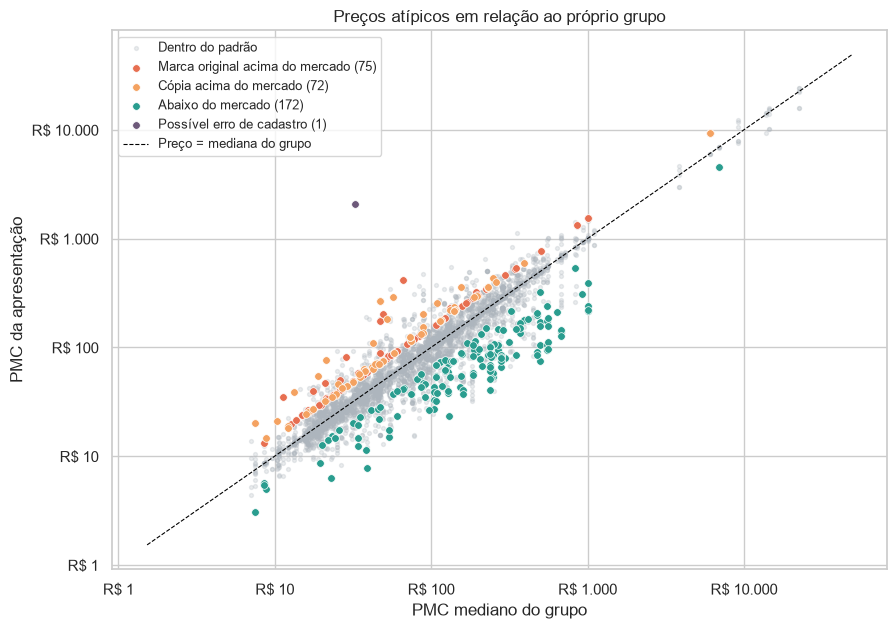

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
normais = rodada2[~rodada2["atipico"]]
ax.scatter(normais["mediana_grupo"], normais["pmc_sem_impostos"], s=8, alpha=0.25,
           color="#adb5bd", label="Dentro do padrão")

CORES_CAT = {
    "Marca original acima do mercado": "#e76f51",
    "Cópia acima do mercado": "#f4a261",
    "Abaixo do mercado": "#2a9d8f",
    "Possível erro de cadastro": "#6d597a",
}
for categoria, cor in CORES_CAT.items():
    parte = atipicos[atipicos["categoria"] == categoria]
    ax.scatter(parte["mediana_grupo"], parte["pmc_sem_impostos"], s=30, color=cor,
               label=f"{categoria} ({len(parte)})", edgecolor="white", linewidth=0.5)

limites = [rodada2["pmc_sem_impostos"].min() / 2, rodada2["pmc_sem_impostos"].max() * 2]
ax.plot(limites, limites, color="black", lw=0.8, ls="--", label="Preço = mediana do grupo")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("PMC mediano do grupo")
ax.set_ylabel("PMC da apresentação")
ax.set_title("Preços atípicos em relação ao próprio grupo")
reais = mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}".replace(",", "."))
ax.xaxis.set_major_formatter(reais)
ax.yaxis.set_major_formatter(reais)
ax.legend(fontsize=9, loc="upper left")
salvar(fig, "10_precos_atipicos")
plt.show()

Um padrão fica evidente: **todos os medicamentos novos marcados estão acima do mercado**,
e a maioria dos genéricos marcados está **abaixo**. As marcas originais mantêm preço alto
mesmo quando há muitas cópias mais baratas, e alguns genéricos entram com preços bem menores
que os concorrentes.

## 6. Um exemplo concreto

CLORIDRATO DE CIPROFLOXACINO | 500 MG COM REV | 14 | 1 un


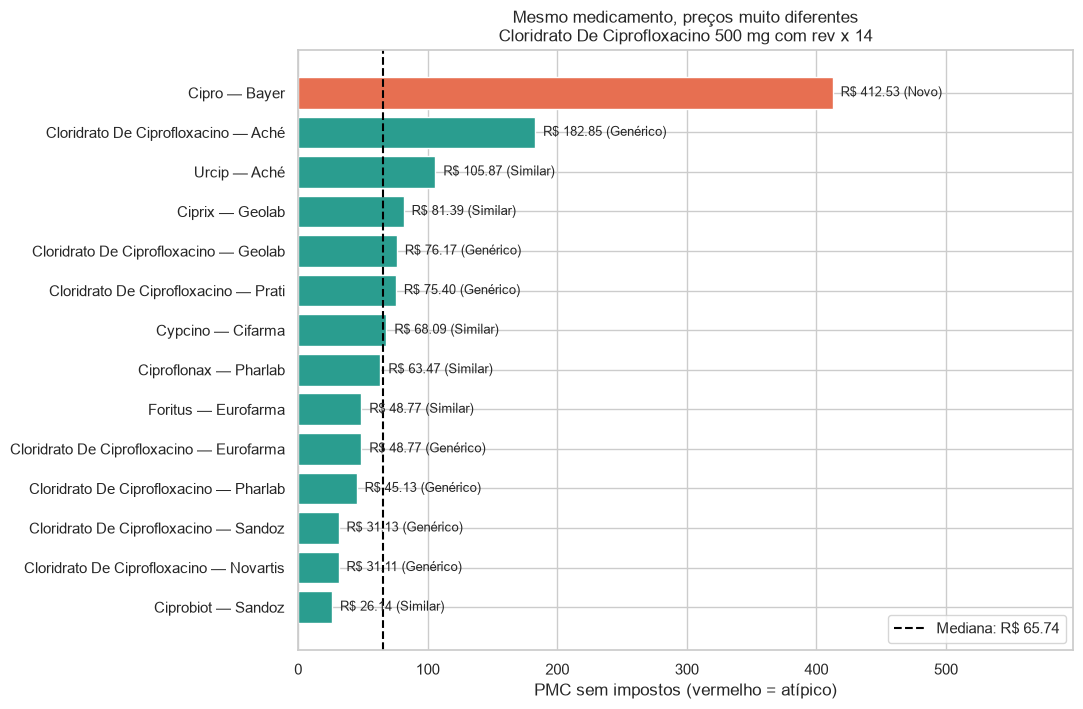

In [10]:
grupo_exemplo = (atipicos[atipicos["categoria"] == "Marca original acima do mercado"]
                 .nlargest(1, "razao_mediana")["grupo_corrigido"].iat[0])
exemplo = rodada2[rodada2["grupo_corrigido"] == grupo_exemplo].sort_values("pmc_sem_impostos")
print(grupo_exemplo)

fig, ax = plt.subplots(figsize=(10, 0.45 * len(exemplo) + 1.5))
cores = exemplo["atipico"].map({True: "#e76f51", False: "#2a9d8f"})
rotulos = exemplo["produto"].str.title() + " — " + exemplo["laboratorio"].str.split().str[0].str.title()
ax.barh(rotulos, exemplo["pmc_sem_impostos"], color=cores)
ax.axvline(exemplo["mediana_grupo"].iat[0], color="black", ls="--",
           label=f"Mediana: R$ {exemplo['mediana_grupo'].iat[0]:,.2f}")
for i, (v, t) in enumerate(zip(exemplo["pmc_sem_impostos"], exemplo["tipo_produto"])):
    ax.text(v, i, f"  R$ {v:,.2f} ({t})", va="center", fontsize=9)
ax.set_xlim(0, exemplo["pmc_sem_impostos"].max() * 1.45)
ax.set_title(f"Mesmo medicamento, preços muito diferentes\n{grupo_exemplo.split(' | ')[0].title()} "
             f"{grupo_exemplo.split(' | ')[1].lower()} x {grupo_exemplo.split(' | ')[2]}")
ax.set_xlabel("PMC sem impostos (vermelho = atípico)")
ax.legend(loc="lower right")
salvar(fig, "11_exemplo_grupo")
plt.show()

Neste grupo, a marca original custa várias vezes a mediana, e os próprios genéricos
variam muito entre si: na lista de 09/09/2026, de cerca de R$ 31 a R$ 183 pela mesma caixa.

O mesmo medicamento aparece em outro grupo, cadastrado como *cloridrato de ciprofloxacino monoidratado*,
com dois genéricos marcados como "cópia acima do mercado" a R$ 268. Esse valor é **65% do preço da marca
original**, exatamente o desconto mínimo que vimos no `02_eda`: esses genéricos usam o teto regulatório,
enquanto outros cobram uma fração disso.

## 7. Os casos mais extremos de cada categoria

In [11]:
for categoria in CORES_CAT:
    parte = atipicos[atipicos["categoria"] == categoria]
    if parte.empty:
        continue
    crescente = categoria == "Abaixo do mercado"
    print(f"\n=== {categoria} ({len(parte)}) ===")
    display(parte.sort_values("razao_mediana", ascending=crescente).head(6)[COLUNAS_VER])


=== Marca original acima do mercado (75) ===


,produto,laboratorio,tipo_produto,apresentacao,pmc_sem_impostos,mediana_grupo,razao_mediana
2822,CIPRO,BAYER S.A.,Novo,500 MG COM REV CT BL AL PLAS PVC/PVDC OPC X 14,412.53,65.74,6.28
8400,OLMETEC,PFIZER BRASIL LTDA,Novo,40 MG COM REV CT BL AL/AL X 30,200.49,49.09,4.08
8399,OLMETEC,PFIZER BRASIL LTDA,Novo,20 MG COM REV CT BL AL/AL X 30,174.28,46.68,3.73
8761,TYLENOL,JANSSEN-CILAG FARMACEUTICA LTDA,Novo,200 MG/ML SOL OR CT FR PLAS OPC GOT X 15 ML,34.67,11.21,3.09
8168,DERMODEX,TAKEDA PHARMA LTDA.,Novo,100.000 UI/G + 200 MG/G POM DERM CT BG AL X 60 G,81.47,28.56,2.85
6619,ALIVIUM,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS S.A.,Novo,50 MG/ML SUS OR CT FR GOT PLAS PEBD/PEAD OPC X 30 ML,39.98,17.47,2.29



=== Cópia acima do mercado (72) ===


,produto,laboratorio,tipo_produto,apresentacao,pmc_sem_impostos,mediana_grupo,razao_mediana
2830,CLORIDRATO DE CIPROFLOXACINO,BIOLAB SANUS FARMACEUTICA LTDA,Genérico,500 MG COM REV CT BL AL PLAS TRANS X 14,268.14,46.95,5.71
2829,CLORIDRATO DE CIPROFLOXACINO,GERMED FARMACEUTICA LTDA,Genérico,500 MG COM REV CT BL AL PLAS PVDC OPC X 14,268.12,46.95,5.71
5938,TANAKAN,ABBOTT LABORATORIOS DO BRASIL LTDA,Fitoterápico,120 MG COM REV CT BL AL PLAS PVC/PVDC INC X 30,287.73,56.94,5.05
10736,VALERIANE,ZYDUS NIKKHO FARMACÊUTICA LTDA,Fitoterápico,50 MG COM REV CT BL AL PLAS TRANS X 20,76.37,21.30,3.59
2114,VASOGARD,ACHÉ LABORATÓRIOS FARMACÊUTICOS S.A,Similar,100 MG COM CT BL AL PLAS TRANS X 60,182.51,51.75,3.53
4689,MAGNOPYROL,COSMED INDUSTRIA DE COSMETICOS E MEDICAMENTOS S.A.,Similar,500 MG/ML SOL OR CT FR PLAS OPC GOT X 20 ML,38.47,13.16,2.92



=== Abaixo do mercado (172) ===


,produto,laboratorio,tipo_produto,apresentacao,pmc_sem_impostos,mediana_grupo,razao_mediana
2913,CLORIDRATO DE DONEPEZILA,UNICHEM FARMACÊUTICA DO BRASIL LTDA,Genérico,5 MG COM REV CT BL AL PLAS PVC/PVDC TRANS X 30,74.25,496.13,0.15
8587,OXALATO DE ESCITALOPRAM,CIMED INDUSTRIA S.A,Genérico,10 MG COM REV CT BL AL PLAS PVC/PE/PVDC TRANS X 30,40.33,236.44,0.17
2914,CLORIDRATO DE DONEPEZILA,UNICHEM FARMACÊUTICA DO BRASIL LTDA,Genérico,10 MG COM REV CT BL AL PLAS PVC/PVDC TRANS X 30,94.20,551.30,0.17
9690,ROSUVASTATINA CÁLCICA,UNICHEM FARMACÊUTICA DO BRASIL LTDA,Genérico,20 MG COM REV CT BL AL AL X 60,97.33,558.88,0.17
8606,OXALATO DE ESCITALOPRAM,SANOFI MEDLEY FARMACÊUTICA LTDA.,Genérico,10 MG COM REV CT BL AL PLAS TRANS X 60,84.11,474.11,0.18
1039,BESILATO DE ANLODIPINO,SANDOZ DO BRASIL INDÚSTRIA FARMACÊUTICA LTDA,Genérico,5 MG COM CT BL AL PLAS PVC OPC X 60,23.52,130.17,0.18



=== Possível erro de cadastro (1) ===


,produto,laboratorio,tipo_produto,apresentacao,pmc_sem_impostos,mediana_grupo,razao_mediana
8741,GRIPALCÊ UNO,BRASTERAPICA PHARMACEUTICA LTDA.,Similar,32 MG/ML SUS OR CT FR PLAS TRANS X 60 ML + CP MED,"2,079.83",32.57,63.85


## 8. Conclusões

1. **A detecção de anomalias encontrou um erro na preparação dos dados.** Embalagens múltiplas
   (ex.: 50 bisnagas em um cartucho) estavam sendo comparadas com unidades individuais.
   Após a correção, os 24 casos que eram só artefato de embalagem saíram da lista.
2. **Marcas originais são o principal grupo acima do mercado.** Todos os medicamentos novos marcados
   custam bem mais que a mediana das suas cópias, o que indica que a marca sustenta preço
   mesmo com concorrência.
3. **Existem dois tipos de genérico:** os que ficam no teto regulatório (65% da marca original) e os que
   competem com preços muito menores. Para o consumidor, a diferença entre genéricos do mesmo
   medicamento pode chegar a 6 vezes (caso da ciprofloxacino 500 mg x 14).
4. **Casos com preço acima de 20 vezes a mediana** merecem verificação manual na fonte, pois podem ser
   erros de cadastro ou apresentações que o texto não descreve corretamente.

**Limitações:** o método depende da qualidade do agrupamento por texto; grupos pequenos (4 a 5 itens)
têm estimativas de mediana e MAD instáveis; e o PMC é um teto, não o preço praticado.

**Evoluções possíveis:** calcular preço por unidade (comprimido, mL, grama) para comparar embalagens
de tamanhos diferentes, e acompanhar os atípicos em várias edições da lista.

In [12]:
data_str = ARQUIVO.stem.split("_")[-1]
saida = PASTA_PROCESSED / f"cmed_atipicos_{data_str}.csv"
colunas_saida = ["grupo_corrigido", "categoria", "substancia"] + COLUNAS_VER + ["z_robusto", "tamanho_grupo"]
atipicos[colunas_saida].sort_values(["categoria", "razao_mediana"], ascending=[True, False]).to_csv(
    saida, index=False, encoding="utf-8")
print(f"{len(atipicos)} casos salvos em {saida}")

320 casos salvos em ..\data\processed\cmed_atipicos_20260909.csv
